In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

from google.colab import drive
drive.mount('/content/gdrive')

%cd gdrive/MyDrive/ITMO_HW/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
[Errno 2] No such file or directory: 'gdrive/MyDrive/ITMO_HW/'
/content/gdrive/MyDrive/ITMO_HW


In [136]:
# считываем файл в датафрейм
df = pd.read_csv('train.csv')

In [137]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


целевая переменная - Survived (выжил пассажир или нет), конвертировать её не нужно (она в числовом виде)  
на выживаемость влияют параметры Pclass (класс каюты), Sex (пол), Age (возраст), SibSp (кол-во родственников, кроме детей и родителей), Parch (кол-во детей и родителей), Embarked (порт отправки пассажира)  
из указанных выше параметров, поля Sex и Embarked нужно преобразовать из текста

In [138]:
res_sex = pd.get_dummies(df['Sex'], prefix='sex', drop_first=True)
res_sex.head()

,sex_male
0,True
1,False
2,False
3,False
4,True


In [139]:
res_embarked = pd.get_dummies(df['Embarked'], prefix='embarked', drop_first=True)
res_embarked.head()

,embarked_Q,embarked_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [140]:
# создадим новый DF с только нужными нам полями, где NaN заменим на 0 (встречается в Age)
df_ml = pd.concat([df[['Pclass', 'Age', 'SibSp', 'Parch', 'Survived']].fillna(0), res_sex, res_embarked], axis=1)
df_ml.head()

,Pclass,Age,SibSp,Parch,Survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,0,True,False,True
1,1,38.0,1,0,1,False,False,False
2,3,26.0,0,0,1,False,False,True
3,1,35.0,1,0,1,False,False,True
4,3,35.0,0,0,0,True,False,True


In [141]:
# посмотрим мультиколлинеарность, целевой столбец при этом не учитываем
corrs = df_ml.drop('Survived', axis=1).corr()
upper_tri = corrs.where(np.triu(np.ones(corrs.shape), k=1).astype(np.bool))
upper_tri

,Pclass,Age,SibSp,Parch,sex_male,embarked_Q,embarked_S
Pclass,NaN,-0.361353,0.083081,0.018443,0.131900,0.221009,0.081720
Age,NaN,NaN,-0.184664,-0.048786,0.024978,-0.237586,0.140578
SibSp,NaN,NaN,NaN,0.414838,-0.114631,-0.026354,0.070941
Parch,NaN,NaN,NaN,NaN,-0.245489,-0.081228,0.063036
sex_male,NaN,NaN,NaN,NaN,NaN,-0.074115,0.125722
embarked_Q,NaN,NaN,NaN,NaN,NaN,NaN,-0.496624
embarked_S,NaN,NaN,NaN,NaN,NaN,NaN,NaN


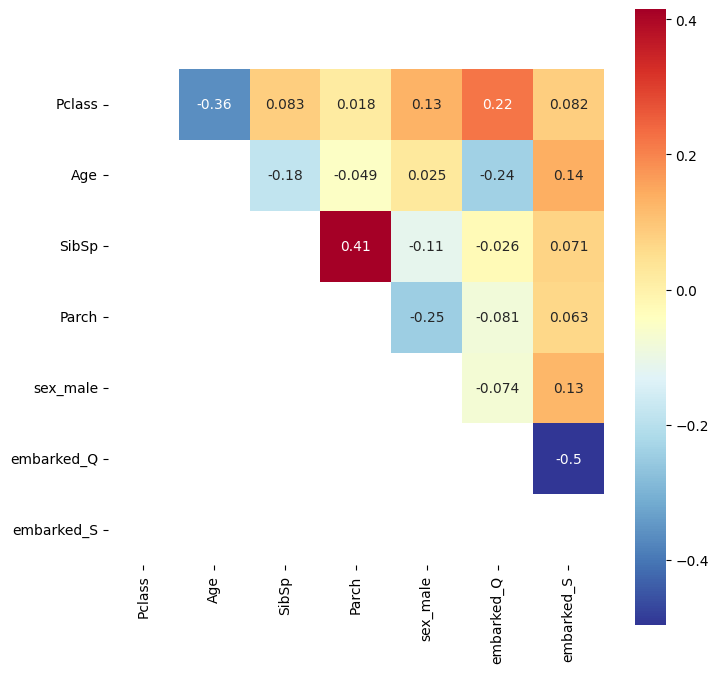

In [142]:
# нарисуем чего получилось
plt.figure(figsize=(8, 8))
sns.heatmap(upper_tri, cmap="RdYlBu_r", square=True, annot=True);

Мультиколлинеарность отсутствует (учитываю мультиколлинеарность как значение более 0.9, такого нет)

In [143]:
# из любопытства ещё проверил мультиколлинеарность по VIF, где от 5 до 10 считается высоким значением мультиколлинеарности, а >10 - серьезным значением (такие можно сразу в печь)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Удаляем целевую переменную, оставляем только признаки
X = df_ml.drop('Survived', axis=1)

# Не ест bool, перевожу в int
X['sex_male'] = X['sex_male'].astype(int)
X['embarked_Q'] = X['embarked_Q'].astype(int)
X['embarked_S'] = X['embarked_S'].astype(int)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

      feature       VIF
0      Pclass  6.021311
1         Age  2.380094
2       SibSp  1.522290
3       Parch  1.548837
4    sex_male  3.009964
5  embarked_Q  1.567336
6  embarked_S  4.829581


Pclass с относительно высоким уровнем мультиколлинеарности, но не запредельный, оставлю его

In [166]:
# Делим на тренинг и тест
y = df_ml['Survived']
X = df_ml[['Pclass', 'sex_male', 'Age', 'SibSp', 'Parch', 'embarked_Q', 'embarked_S']]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2023, test_size=0.25)

In [167]:
# константу выбрал по наиболее частотному классу, обучаем на тренировочных данных
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [168]:
# а здесь уже обучаем по лог регрессии
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [169]:
# посмотрим на соотношение значений целевого поля Survived (проверим наличие дисбаланса)
df_ml['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


**!!!** В качестве основной метрики будем использовать **F1-score** потому что в ней учитывается точность и полнота, при этом они нам нужны в равнозначной степени (иначе взяли бы Fbeta-score, где могли настроить коэффициент учёта точности и полноты) и большого перекоса в данных нет (что мы увидели выше - соотношение 61.6%/38.4%).  
Вообще здесь бы подошла и Accuracy, т.к. большого дисбаланса нет, но она слишком примитивная; добавим её в качестве интереса. Спойлер - в нашем случае она показала более высокую точность.  
Если бы задача подразумевала минимизацию ложных срабатываний, или пропусков, то я бы выбрал Fbeta-score.

In [170]:
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_log_reg = log_reg.predict(X_test)

In [171]:
print(f'accuracy_score for Dummy Classificator: {accuracy_score(y_test, y_pred_dummy)}')
print(f'accuracy_score for Logistic regression: {accuracy_score(y_test, y_pred_log_reg)}')

accuracy_score for Dummy Classificator: 0.6188340807174888
accuracy_score for Logistic regression: 0.7668161434977578


In [172]:
print(f'F1-score for Dummy Classificator: {f1_score(y_test, y_pred_dummy)}')
print(f'F1-score for Logistic regression: {f1_score(y_test, y_pred_log_reg)}')

F1-score for Dummy Classificator: 0.0
F1-score for Logistic regression: 0.6941176470588235


Итог боевой модели по F1-score: 0.6941176470588235